<a href="https://colab.research.google.com/github/udayanjansai/RNN/blob/main/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/datasets/optimized_waste_management_data.csv')
df.head()

,date,waste_volume,organic_waste,recyclable_waste,hazardous_waste,collection_frequency,landfill_capacity_used,recycling_rate
0,01-01-2020,48.85,31.49,12.55,4.81,Weekly,55.87,47.37
1,02-01-2020,49.45,29.76,14.76,4.94,Weekly,51.91,41.70
2,03-01-2020,51.03,32.29,13.65,5.09,Bi-weekly,53.08,58.73
3,04-01-2020,54.70,35.09,14.36,5.25,Bi-weekly,52.04,39.34
4,05-01-2020,51.74,29.99,16.87,4.88,Bi-weekly,48.01,40.45


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Embedding, LSTM

In [15]:
df.shape

(1461, 8)

In [16]:
df.dtypes

,0
date,object
waste_volume,float64
organic_waste,float64
recyclable_waste,float64
hazardous_waste,float64
collection_frequency,object
landfill_capacity_used,float64
recycling_rate,float64


Missing values can affect training we fill them using forward fill

In [17]:
df=df.ffill()


In [18]:
waste_df=df[['waste_volume']]

Neural networks work better when data values are scaled between 0 and 1

In [19]:
scaler=MinMaxScaler()
scaler.fit(waste_df)
scaled_waste=scaler.transform(waste_df)

Convert Data into Sequences

RNN requires sequential input.
Example:

Previous 10 days - Predict next day

In [20]:
def create_sequences(data,seq_length):
  X=[]
  y=[]
  for i in range(len(data)-seq_length):
    X.append(data[i:i+seq_length])
    y.append(data[i+seq_length])
  return np.array(X),np.array(y)

In [21]:
sequence_length=10
X,y=create_sequences(scaled_waste,sequence_length)
print(X.shape)
print(y.shape)

(1451, 10, 1)
(1451, 1)


Build RNN

In [ ]:
from tensorflow.keras.layers import Input

embedding_dim = 128
model=Sequential()
# Use an explicit Input layer to avoid the UserWarning
model.add(Input(shape=(sequence_length, 1)))
model.add(SimpleRNN(50, activation='tanh'))
model.add(Dense(1))


In [23]:
model.compile(optimizer='adam',loss='mean_squared_error')
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

Train the model

In [24]:
split=int(0.8*len(X))
X_train=X[:split]
y_train=y[:split]
X_test=X[split:]
y_test=y[split:]

In [25]:
history=model.fit(
    X_train,y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.1
)

Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.0134 - val_loss: 0.0115
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0096 - val_loss: 0.0112
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0100 - val_loss: 0.0127
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0093 - val_loss: 0.0151
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0093 - val_loss: 0.0127
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0096 - val_loss: 0.0119
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0100 - val_loss: 0.0124
Epoch 8/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0100 - val_loss: 0.0125
Epoch 9/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0096 - val_loss: 0.0123
Epoch 10/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0100 - val_loss: 0.0139
Epoch 11/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0095 - val_loss: 0.0121
Epoch 12/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.

Evaluate the Model


In [26]:
loss=model.evaluate(X_test,y_test)
print('Test Loss:',loss)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0096
Test Loss: 0.009562617167830467


In [27]:
predictions=model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step


In [28]:
predictions=scaler.inverse_transform(predictions)
y_test_actual=scaler.inverse_transform(y_test)

plot predictions vs actual values

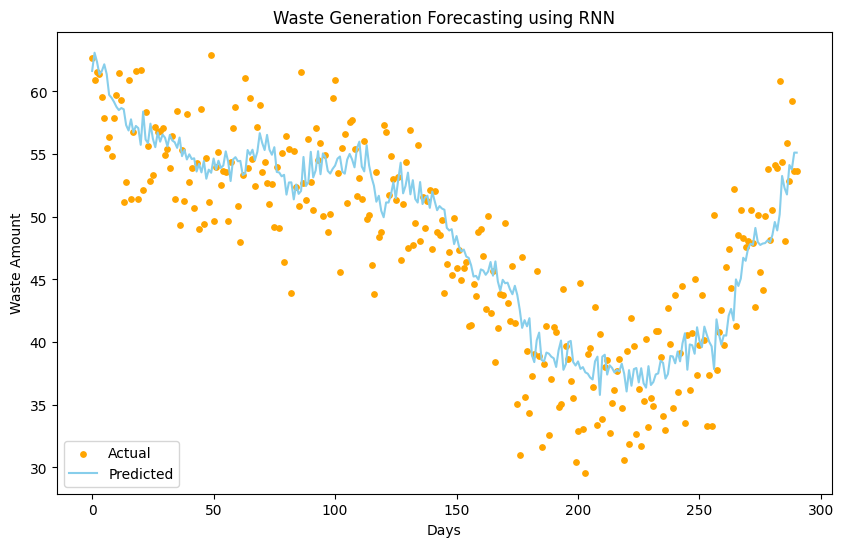

In [29]:
plt.figure(figsize=(10,6))
plt.scatter(range(len(y_test_actual)), y_test_actual, label='Actual', s=15,color='orange')
plt.plot(predictions,label='Predicted', color='skyblue') # Added color='red'
plt.title("Waste Generation Forecasting using RNN")
plt.xlabel('Days')
plt.ylabel('Waste Amount')
plt.legend()
plt.show()
#If two lines are close + good model.

In [30]:
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/datasets/IMDB_Dataset.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [31]:
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [32]:
df['review_length']=df['review'].apply(len)
print(df['review_length'].mean())

1309.43102


In [33]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download necessary NLTK data (if not already downloaded)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

### Displaying the first 5 rows of the processed reviews

In [34]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download necessary NLTK data (if not already downloaded)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

In [35]:
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/datasets/IMDB_Dataset.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [36]:
df['review'] = df['review'].str.lower()

In [37]:
def remove_html_tags(text):
    clean = re.compile('<.*?>')
    return re.sub(clean, '', text)
df['review'] = df['review'].apply(remove_html_tags)

In [38]:
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))
df['review'] = df['review'].apply(remove_punctuation)

In [39]:
df['review'] = df['review'].apply(word_tokenize)

In [40]:
stop_words = set(stopwords.words('english'))
def remove_stopwords(words):
    return [word for word in words if word not in stop_words]
df['review'] = df['review'].apply(remove_stopwords)

### Displaying the first 5 rows of the processed reviews for the whole dataset

In [41]:
display(df.head())

,review,sentiment
0,"[one, reviewers, mentioned, watching, 1, oz, e...",positive
1,"[wonderful, little, production, filming, techn...",positive
2,"[thought, wonderful, way, spend, time, hot, su...",positive
3,"[basically, theres, family, little, boy, jake,...",negative
4,"[petter, matteis, love, time, money, visually,...",positive


In [42]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Create a Tokenizer object
tokenizer = Tokenizer()

# Fit the tokenizer on the reviews to create the vocabulary
tokenizer.fit_on_texts(df['review'])

### Displaying the first 5 rows of the word index mapping

In [43]:
# Get the word index mapping
word_index = tokenizer.word_index

# Display the first 5 entries of the word index mapping
print("Word\tIndex")
print("-----\t-----")
for i, (word, index) in enumerate(word_index.items()):
    if i >= 5:
        break
    print(f"{word}\t{index}")

Word	Index
-----	-----
movie	1
film	2
one	3
like	4
good	5


In [44]:
# Convert reviews to sequences of integers
sequences = tokenizer.texts_to_sequences(df['review'])

# Display the first processed review and its corresponding sequence
print("Original Processed Review (first entry):")
print(df['review'].iloc[0])
print("\nConverted Sequence (first entry):")
print(sequences[0])

Original Processed Review (first entry):
['one', 'reviewers', 'mentioned', 'watching', '1', 'oz', 'episode', 'youll', 'hooked', 'right', 'exactly', 'happened', 'methe', 'first', 'thing', 'struck', 'oz', 'brutality', 'unflinching', 'scenes', 'violence', 'set', 'right', 'word', 'go', 'trust', 'show', 'faint', 'hearted', 'timid', 'show', 'pulls', 'punches', 'regards', 'drugs', 'sex', 'violence', 'hardcore', 'classic', 'use', 'wordit', 'called', 'oz', 'nickname', 'given', 'oswald', 'maximum', 'security', 'state', 'penitentary', 'focuses', 'mainly', 'emerald', 'city', 'experimental', 'section', 'prison', 'cells', 'glass', 'fronts', 'face', 'inwards', 'privacy', 'high', 'agenda', 'em', 'city', 'home', 'manyaryans', 'muslims', 'gangstas', 'latinos', 'christians', 'italians', 'irish', 'moreso', 'scuffles', 'death', 'stares', 'dodgy', 'dealings', 'shady', 'agreements', 'never', 'far', 'awayi', 'would', 'say', 'main', 'appeal', 'show', 'due', 'fact', 'goes', 'shows', 'wouldnt', 'dare', 'forget',

In [45]:
print(sequences[:5])

[[3, 1809, 940, 56, 398, 3216, 286, 349, 3027, 107, 481, 470, 7413, 19, 57, 3098, 3216, 5386, 14836, 50, 472, 180, 107, 548, 52, 1605, 41, 8025, 5581, 11458, 41, 2359, 5835, 5493, 1339, 276, 472, 3260, 246, 233, 60879, 353, 3216, 11124, 240, 15441, 6674, 2419, 938, 60880, 2483, 1246, 24499, 422, 4558, 2376, 1079, 6877, 2830, 12562, 298, 60881, 16895, 213, 4902, 3570, 422, 236, 83188, 8154, 39826, 14837, 4990, 7606, 2319, 16896, 60882, 224, 8952, 7194, 12977, 8403, 33776, 34, 126, 21148, 7, 45, 166, 1172, 41, 550, 91, 159, 154, 436, 2845, 703, 85, 1144, 4167, 2353, 974, 703, 1282, 703, 83189, 58, 852, 88, 19, 286, 43, 103, 3098, 1451, 2067, 288, 45, 1422, 174, 1336, 1121, 3216, 83, 9932, 213, 1949, 1961, 472, 472, 7675, 6878, 4784, 13678, 2799, 31543, 6770, 13678, 380, 499, 14, 140, 13, 9590, 632, 693, 6770, 542, 1079, 19848, 550, 438, 808, 1860, 1079, 443, 56, 3216, 98, 302, 3603, 3116, 83190, 14, 1082, 3863, 392], [277, 37, 252, 1233, 2865, 17761, 83191, 1501, 283, 12978, 407, 26713, 

In [46]:
display(df.head())

,review,sentiment
0,"[one, reviewers, mentioned, watching, 1, oz, e...",positive
1,"[wonderful, little, production, filming, techn...",positive
2,"[thought, wonderful, way, spend, time, hot, su...",positive
3,"[basically, theres, family, little, boy, jake,...",negative
4,"[petter, matteis, love, time, money, visually,...",positive


### Padding sequences to a uniform length

In [47]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Find the maximum sequence length
max_sequence_length = max([len(seq) for seq in sequences])
print(f"Maximum sequence length: {max_sequence_length}")

# Pad the sequences to the maximum length
padded_sequences = pad_sequences(sequences, maxlen=max_sequence_length, padding='post')

print("\nShape of padded sequences:")
print(padded_sequences.shape)
print("\nFirst 5 padded sequences:\n", padded_sequences[:5])

Maximum sequence length: 1429

Shape of padded sequences:
(50000, 1429)

First 5 padded sequences:
 [[    3  1809   940 ...     0     0     0]
 [  277    37   252 ...     0     0     0]
 [   96   277    26 ...     0     0     0]
 [  571   124   136 ...     0     0     0]
 [83196 33777    35 ...     0     0     0]]


### Use of Padded Sequences

1.  **Uniform Input Shape for Neural Networks**: When you're training a neural network on text data, each piece of text (like a review) is converted into a sequence of numbers. Naturally, reviews have different lengths (some are short, some are long).

    *   Neural networks, particularly layers like Embedding layers, require all input sequences in a batch to have the same length. This is where padding comes in.

2.  **Batch Processing**: Training neural networks is most efficient when processing data in batches. If sequences in a batch have different lengths, it's difficult for the hardware (CPU/GPU) to process them simultaneously.

    *   By padding, all sequences become the same length, enabling efficient batch processing.

3.  **How Padding Works**: `pad_sequences` takes your list of numerical sequences and does the following:

    *   **Short Sequences**: If a sequence is shorter than the `max_sequence_length` (which we determined to be 1429), it adds a special padding value (usually `0`) to the beginning or end of the sequence until it reaches the `max_sequence_length`.
    *   **Long Sequences**: If a sequence is longer than the `max_sequence_length`, it truncates the sequence (removes words from the beginning or end) to fit the `max_sequence_length`.

In essence, `padded_sequences` ensures that your text data is in the correct, consistent format (a 2D NumPy array with shape `(num_samples, max_sequence_length)`) that a deep learning model can readily accept and process efficiently.

In [48]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, LSTM

# Define the vocabulary size (number of unique words + 1 for padding)
vocab_size = len(word_index) + 1 # +1 for the 0 padding
embedding_dim = 128 # You can choose an appropriate dimension

# Build the new RNN model using LSTM
model_imdb = Sequential()
model_imdb.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim))
model_imdb.add(LSTM(100, activation='tanh')) # Changed to LSTM layer with 100 units
model_imdb.add(Dense(1, activation='sigmoid')) # Output layer for binary classification (sentiment)

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode target variable
le = LabelEncoder()
y = le.fit_transform(df['sentiment'])

# Split data into training and testing sets
X_train_imdb, X_test_imdb, y_train_imdb, y_test_imdb = train_test_split(padded_sequences, y, test_size=0.2, random_state=42)

print(f"Shape of X_train_imdb: {X_train_imdb.shape}")
print(f"Shape of X_test_imdb: {X_test_imdb.shape}")
print(f"Shape of y_train_imdb: {y_train_imdb.shape}")
print(f"Shape of y_test_imdb: {y_test_imdb.shape}")

Shape of X_train_imdb: (40000, 1429)
Shape of X_test_imdb: (10000, 1429)
Shape of y_train_imdb: (40000,)
Shape of y_test_imdb: (10000,)


In [51]:
# Compile the model (moved here from a later cell)
model_imdb.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

epochs = 2 # Increased epochs
batch_size = 64

history_imdb = model_imdb.fit(
    X_train_imdb,
    y_train_imdb,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1 # Use 10% of training data for validation
)

Epoch 1/2
563/563 ━━━━━━━━━━━━━━━━━━━━ 51s 77ms/step - accuracy: 0.4965 - loss: 0.6935 - val_accuracy: 0.5038 - val_loss: 0.6931
Epoch 2/2
563/563 ━━━━━━━━━━━━━━━━━━━━ 42s 74ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.4963 - val_loss: 0.6933


In [53]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode target variable
le = LabelEncoder()
y = le.fit_transform(df['sentiment'])

# Split data into training and testing sets
X_train_imdb, X_test_imdb, y_train_imdb, y_test_imdb = train_test_split(padded_sequences, y, test_size=0.2, random_state=42)

print(f"Shape of X_train_imdb: {X_train_imdb.shape}")
print(f"Shape of X_test_imdb: {X_test_imdb.shape}")
print(f"Shape of y_train_imdb: {y_train_imdb.shape}")
print(f"Shape of y_test_imdb: {y_test_imdb.shape}")

Shape of X_train_imdb: (40000, 1429)
Shape of X_test_imdb: (10000, 1429)
Shape of y_train_imdb: (40000,)
Shape of y_test_imdb: (10000,)


In [54]:
# This cell is now empty as compile() has been moved to the fit cell

In [55]:
# Print the model summary
model_imdb.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 1429, 128)      │    28,457,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        91,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,646,369 (326.71 MB)

 Trainable params: 28,548,789 (108.90 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 57,097,580 (217.81 MB)

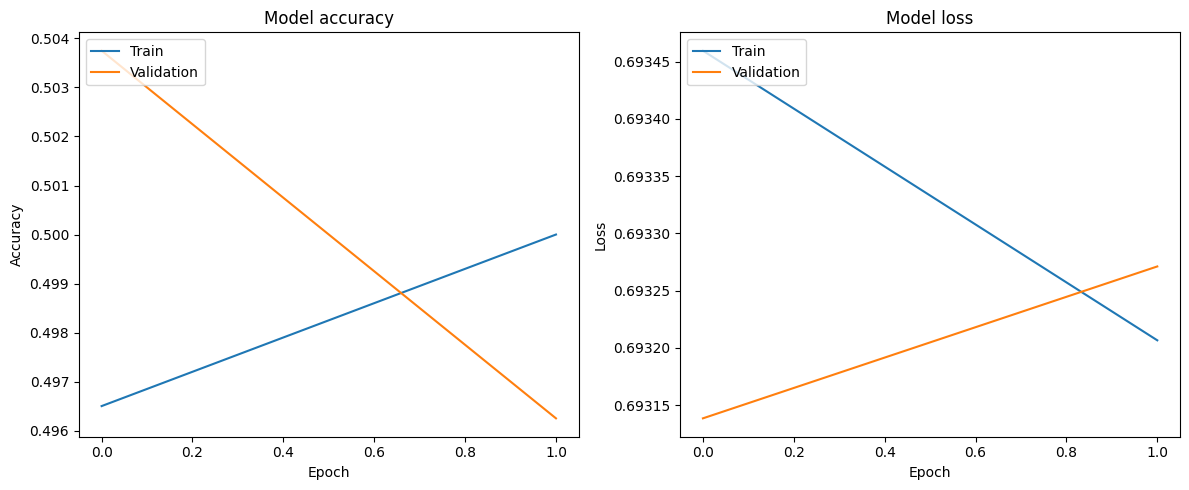

In [56]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_imdb.history['accuracy'])
plt.plot(history_imdb.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_imdb.history['loss'])
plt.plot(history_imdb.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [57]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Evaluate the model on the test set
loss, accuracy = model_imdb.evaluate(X_test_imdb, y_test_imdb, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.6933
Test Accuracy: 0.4961


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step
Confusion Matrix:
[[4961    0]
 [5039    0]]


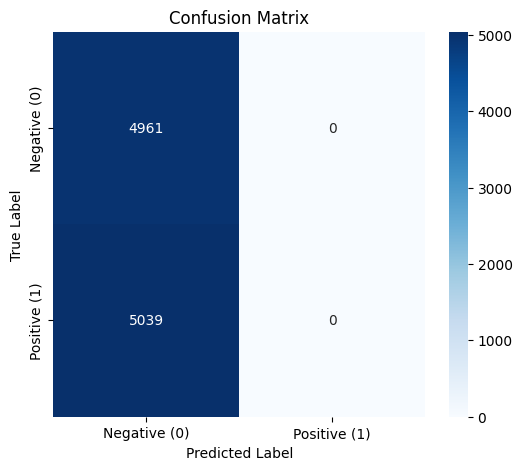

In [58]:
# Make predictions on the test set
y_pred_prob = model_imdb.predict(X_test_imdb)
y_pred = (y_pred_prob > 0.5).astype(int)

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test_imdb, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Plotting the confusion matrix for better visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [59]:
# Compute precision, recall, and F1-score
class_report = classification_report(y_test_imdb, y_pred, target_names=['Negative', 'Positive'])
print("Classification Report:")
print(class_report)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.50      1.00      0.66      4961
    Positive       0.00      0.00      0.00      5039

    accuracy                           0.50     10000
   macro avg       0.25      0.50      0.33     10000
weighted avg       0.25      0.50      0.33     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [60]:
# Analyze misclassified reviews
misclassified_indices = np.where(y_pred.flatten() != y_test_imdb)[0]
print(f"Number of misclassified reviews: {len(misclassified_indices)}")

# Display a few misclassified reviews
num_examples_to_show = 5
print(f"\nShowing {num_examples_to_show} examples of misclassified reviews:")

# Create a reverse word index to convert sequences back to words for better readability
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

def sequence_to_text(sequence):
    return ' '.join([reverse_word_index.get(i, '?') for i in sequence if i != 0])

for i, idx in enumerate(misclassified_indices[:num_examples_to_show]):
    original_review_sequence = X_test_imdb[idx]
    # Filter out padding zeros and unknown words if any
    clean_sequence = [word_id for word_id in original_review_sequence if word_id != 0 and word_id in reverse_word_index]

    # Get the original processed words from the df for a clearer representation
    # This part is a bit tricky as X_test_imdb is already padded and numerical.
    # We'll use the reverse_word_index to reconstruct, but it won't be identical to the original pre-tokenized text.
    reconstructed_text = sequence_to_text(clean_sequence)

    true_sentiment = le.inverse_transform([y_test_imdb[idx]])[0]
    predicted_sentiment = le.inverse_transform([y_pred[idx][0]])[0]

    print(f"\n--- Misclassified Review {i+1} ---")
    print(f"True Sentiment: {true_sentiment}")
    print(f"Predicted Sentiment: {predicted_sentiment}")
    print(f"Review (reconstructed): {reconstructed_text[:500]}...") # Limit output length


Number of misclassified reviews: 5039

Showing 5 examples of misclassified reviews:

--- Misclassified Review 1 ---
True Sentiment: positive
Predicted Sentiment: negative
Review (reconstructed): really liked summerslam due look arena curtains look overall interesting reason anyways could one best summerslams ever wwf didnt lex luger main event yokozuna time ok huge fat man vs strong man im glad times changed terrible main event like every match luger terrible matches card razor ramon vs ted dibiase steiner brothers vs heavenly bodies shawn michaels vs curt hening event shawn named big monster body guard diesel irs vs 123 kid bret hart first takes doink takes jerry lawler stuff harts law...

--- Misclassified Review 2 ---
True Sentiment: positive
Predicted Sentiment: negative
Review (reconstructed): many television shows appeal quite many different kinds fans like farscape doesi know youngsters 3040 years oldfans male female many different countries think adore tv miniseries elements fo

In [61]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Ensure NLTK data is downloaded (if not already)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

# Reuse the preprocessing functions from earlier cells
def remove_html_tags(text):
    clean = re.compile('<.*?>')
    return re.sub(clean, '', text)

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

def preprocess_review(review):
    review = review.lower()
    review = remove_html_tags(review)
    review = remove_punctuation(review)
    words = word_tokenize(review)
    stop_words = set(stopwords.words('english'))
    words = [word for word in words if word not in stop_words]
    return words

def predict_sentiment(review_text, model, tokenizer, max_sequence_length, label_encoder):
    # Preprocess the review
    processed_words = preprocess_review(review_text)

    # Convert words to sequences
    sequence = tokenizer.texts_to_sequences([processed_words])

    # Pad the sequence
    padded_sequence = pad_sequences(sequence, maxlen=max_sequence_length, padding='post')

    # Predict sentiment
    prediction = model.predict(padded_sequence)
    confidence = float(prediction[0][0])

    # Interpret prediction
    if confidence >= 0.5:
        sentiment_label = label_encoder.inverse_transform([1])[0] # Assuming 1 is positive
    else:
        sentiment_label = label_encoder.inverse_transform([0])[0] # Assuming 0 is negative

    return sentiment_label, confidence


Now, let's test the `predict_sentiment` function with some custom reviews.

In [62]:
custom_reviews = [
    "This movie was an absolute masterpiece! I loved every single moment of it. Highly recommended.",
    "Terrible acting, boring plot, and a complete waste of time. I regret watching this film.",
    "It was okay, nothing special. Some good parts, but mostly forgettable.",
    "A truly captivating story with brilliant performances. I was on the edge of my seat throughout.",
    "The worst experience ever. I wouldn't wish this on my worst enemy."
]

for i, review in enumerate(custom_reviews):
    sentiment, confidence = predict_sentiment(review, model_imdb, tokenizer, max_sequence_length, le)
    print(f"\n--- Custom Review {i+1} ---")
    print(f"Review: '{review}'")
    print(f"Predicted Sentiment \u2192 {sentiment.capitalize()}")
    print(f"Confidence \u2192 {confidence:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

--- Custom Review 1 ---
Review: 'This movie was an absolute masterpiece! I loved every single moment of it. Highly recommended.'
Predicted Sentiment → Negative
Confidence → 0.50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step

--- Custom Review 2 ---
Review: 'Terrible acting, boring plot, and a complete waste of time. I regret watching this film.'
Predicted Sentiment → Negative
Confidence → 0.50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step

--- Custom Review 3 ---
Review: 'It was okay, nothing special. Some good parts, but mostly forgettable.'
Predicted Sentiment → Negative
Confidence → 0.50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step

--- Custom Review 4 ---
Review: 'A truly captivating story with brilliant performances. I was on the edge of my seat throughout.'
Predicted Sentiment → Negative
Confidence → 0.50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step

--- Custom Review 5 ---
Review: 'The worst experience ever. I wouldn't wish this on my worst enemy.'
Predicted Sentiment